<a href="https://colab.research.google.com/github/donicas/ftiproj/blob/main/FTIproj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
url = 'https://raw.githubusercontent.com/donicas/ftiproj/refs/heads/main/ZipWaterQuality.csv'
df = pd.read_csv(url)
df_copy = df.copy()
df_copy_three = df.copy()

In [ ]:
# Importance of data, "why should people care?"
# peep geographical patterns that may exist/ per state or region bleh
# context of the areas themselves
# current EPA funding? that could impact area codes
# rural/suberban
# low/high income areas
# map variables

In [ ]:
url = 'https://raw.githubusercontent.com/donicas/ftiproj/refs/heads/main/ZipWaterQuality.csv'
df = pd.read_csv(url)
df.head()

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
0,1001,Agawam,MA,Agawam Water Department,MA1005000,28692.0,SW,1.0,0.0,1.0,0,NaN,42.0702,-72.6227,True
1,1002,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3671,-72.4646,True
2,1003,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3919,-72.5248,True
3,1004,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3845,-72.5132,True
4,1005,Barre,MA,Barre Water Department,MA2021000,4098.0,GW,18.0,0.0,10.0,0,NaN,42.4097,-72.1084,True


In [ ]:
df.info()
# water source
#health contaminant names
#has active issues

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       41344 non-null  int64  
 1   city                      41344 non-null  object 
 2   state                     41344 non-null  object 
 3   system_name               41344 non-null  object 
 4   pwsid                     41344 non-null  object 
 5   population                41344 non-null  float64
 6   water_source              41343 non-null  object 
 7   total_violations          41344 non-null  float64
 8   health_violations         41344 non-null  float64
 9   unresolved_violations     41344 non-null  float64
 10  contaminant_count         41344 non-null  int64  
 11  health_contaminant_names  11072 non-null  object 
 12  latitude                  41344 non-null  float64
 13  longitude                 41344 non-null  float64
 14  has_ac

In [ ]:
df.describe()

,zip,population,total_violations,health_violations,unresolved_violations,contaminant_count,latitude,longitude
count,41344.000000,4.134400e+04,41344.000000,41344.000000,41344.000000,41344.000000,41344.000000,41344.000000
mean,49849.686847,2.301964e+05,6.662539,1.075126,2.474023,0.427099,38.592323,-91.154586
std,27818.005406,8.235376e+05,18.668761,3.556683,9.080675,0.896748,5.236934,15.345359
min,1001.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,19.066800,-176.634000
25%,26447.750000,1.332000e+03,0.000000,0.000000,0.000000,0.000000,35.044300,-97.327700
50%,49049.000000,7.809500e+03,1.000000,0.000000,0.000000,0.000000,39.144250,-87.991750
75%,73103.250000,9.534500e+04,6.000000,1.000000,2.000000,1.000000,41.888200,-80.143400
max,99950.000000,8.271000e+06,292.000000,97.000000,189.000000,8.000000,71.234600,166.641900


In [ ]:
df[df.duplicated()]
#no duplicated rows

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues


In [ ]:
df.isna()
# only column here with null (the "true") is health contaminant names, which I feel makes sense but might not
# if null and no contaminations that "makes sense"
# if null and contaminated uh thats weird guys!


,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41339,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
41340,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
41341,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
41342,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_copy = df.copy()

# Health Contaminant focus

In [ ]:
df["health_contaminant_names"].describe()

,health_contaminant_names
count,11072
unique,651
top,Stage 2 DBP Rule
freq,2669


In [ ]:
df["health_contaminant_names"].unique()

array([nan, 'E. coli', 'Contaminant 0800',
       'Consumer Confidence Report Rule', 'Total Trihalomethanes (TTHM)',
       'Chlorine residual;Haloacetic Acids (HAA5)',
       'Haloacetic Acids (HAA5)', 'Barium',
       'Consumer Confidence Report Rule;Contaminant 0700', 'HAA6Br',
       'Stage 1 DBP Rule', 'Contaminant 1011',
       'Consumer Confidence Report Rule;Stage 2 DBP Rule;Chlorine residual',
       'Gross Beta;Consumer Confidence Report Rule',
       'Stage 1 DBP Rule;Lead',
       'Stage 2 DBP Rule;Consumer Confidence Report Rule',
       'Lead;Stage 1 DBP Rule',
       'Stage 1 DBP Rule;Consumer Confidence Report Rule;Gross Alpha',
       'Stage 1 DBP Rule;Consumer Confidence Report Rule;Contaminant 0700',
       'Chlorine residual', 'Gross Alpha',
       'Total Trihalomethanes (TTHM);Haloacetic Acids (HAA5);Contaminant 0700;Barium',
       'Combined Radium', 'Gross Beta;Contaminant 0700',
       'Consumer Confidence Report Rule;Barium;Contaminant 0700',
       'Haloacetic

In [ ]:
df[['population', 'unresolved_violations', 'health_contaminant_names']]
# population correlate with unresolved issues/contaniment type(s)?


,population,unresolved_violations,health_contaminant_names
0,28692.0,1.0,NaN
1,39263.0,0.0,E. coli
2,39263.0,0.0,E. coli
3,39263.0,0.0,E. coli
4,4098.0,10.0,NaN
...,...,...,...
41339,8937.0,0.0,NaN
41340,3218.0,0.0,NaN
41341,100.0,7.0,NaN
41342,2300.0,0.0,Total Trihalomethanes (TTHM);Stage 2 DBP Rule


# Duplicate dropping nulls (all of the nan contaminations!!)

In [ ]:
df_copy.dropna()
# so i had an idea and thought "in case this dropped something that wasnt the health contaminat names, i will be redoing this operation to check (in another method)"

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
1,1002,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3671,-72.4646,True
2,1003,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3919,-72.5248,True
3,1004,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3845,-72.5132,True
9,1011,Chester,MA,Chester Water Department,MA1059000,750.0,SW,3.0,1.0,2.0,1,Contaminant 0800,42.2794,-72.9888,True
44,1069,Palmer,MA,Palmer Water District No.1,MA1227000,4789.0,SW,2.0,2.0,2.0,1,E. coli,42.1762,-72.3288,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41334,99919,Thorne Bay,AK,"City of Thorne Bay,",AK2120216,470.0,SW,28.0,1.0,4.0,1,Total Trihalomethanes (TTHM),55.6609,-132.5138,False
41336,99922,Hydaburg,AK,Hydaburg,AK2120224,415.0,SW,83.0,6.0,15.0,1,Total Trihalomethanes (TTHM),55.2087,-132.8259,True
41338,99925,Klawock,AK,Klawock,AK2120169,904.0,SW,26.0,19.0,20.0,1,Total Trihalomethanes (TTHM),55.5526,-133.0555,True
41342,99929,Wrangell,AK,Wrangell,AK2120143,2300.0,SW,6.0,3.0,0.0,2,Total Trihalomethanes (TTHM);Stage 2 DBP Rule,56.4335,-132.3529,False


In [ ]:
df_copy_two = df.copy()
df_copy_two.dropna(subset=["health_contaminant_names"])
# now this copy has null values that're coming from somewhere else possibilities=(water source (1)/has active issues(multiple))


,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
1,1002,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3671,-72.4646,True
2,1003,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3919,-72.5248,True
3,1004,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3845,-72.5132,True
9,1011,Chester,MA,Chester Water Department,MA1059000,750.0,SW,3.0,1.0,2.0,1,Contaminant 0800,42.2794,-72.9888,True
44,1069,Palmer,MA,Palmer Water District No.1,MA1227000,4789.0,SW,2.0,2.0,2.0,1,E. coli,42.1762,-72.3288,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41334,99919,Thorne Bay,AK,"City of Thorne Bay,",AK2120216,470.0,SW,28.0,1.0,4.0,1,Total Trihalomethanes (TTHM),55.6609,-132.5138,False
41336,99922,Hydaburg,AK,Hydaburg,AK2120224,415.0,SW,83.0,6.0,15.0,1,Total Trihalomethanes (TTHM),55.2087,-132.8259,True
41338,99925,Klawock,AK,Klawock,AK2120169,904.0,SW,26.0,19.0,20.0,1,Total Trihalomethanes (TTHM),55.5526,-133.0555,True
41342,99929,Wrangell,AK,Wrangell,AK2120143,2300.0,SW,6.0,3.0,0.0,2,Total Trihalomethanes (TTHM);Stage 2 DBP Rule,56.4335,-132.3529,False


In [ ]:
 # unhealthy water may correlate to disease spread or latest data centers build accross unityed states of americA

health_contaminant_names
Stage 2 DBP Rule                                                         2669
Contaminant 0700                                                          780
Haloacetic Acids (HAA5)                                                   698
Consumer Confidence Report Rule                                           616
Stage 1 DBP Rule                                                          510
                                                                         ... 
Contaminant 4109;Combined Radium                                            1
Fecal Coliform;Consumer Confidence Report Rule;Chlorine residual            1
Atrazine;Stage 1 DBP Rule                                                   1
Contaminant 0700;E. coli;Chlorite                                           1
Total Trihalomethanes (TTHM);Stage 1 DBP Rule;Haloacetic Acids (HAA5)       1
Name: count, Length: 651, dtype: int64


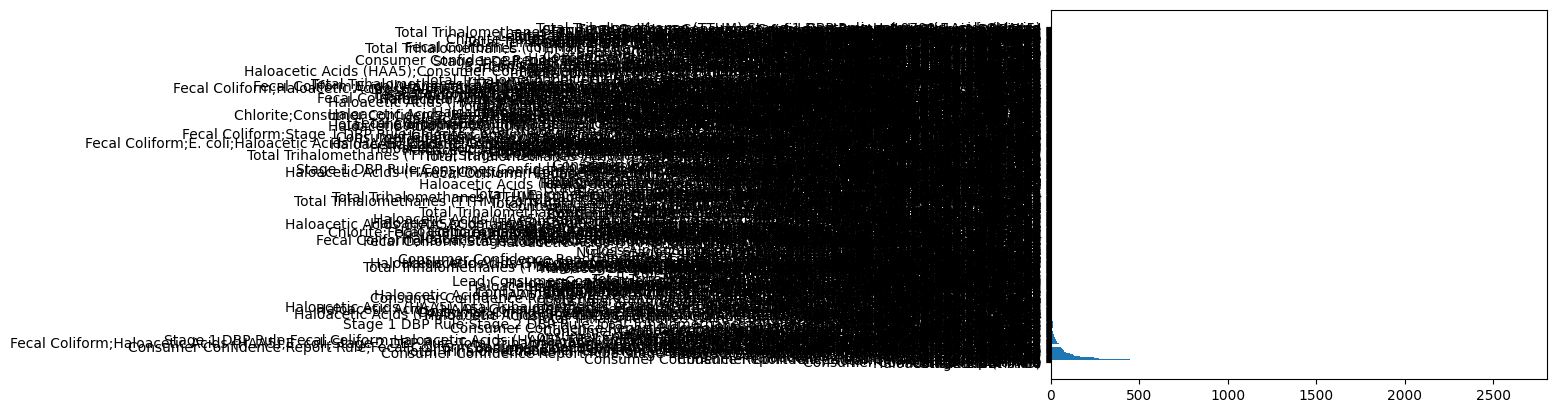

In [ ]:
import matplotlib.pyplot as plt
counts = df_copy['health_contaminant_names'].value_counts()
plt.barh(counts.index, counts.values)
print(counts)


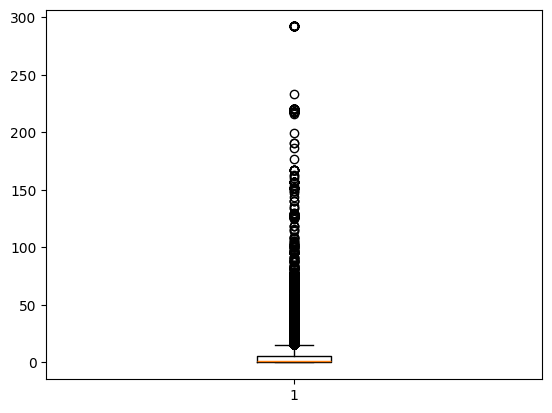

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df_copy['total_violations'])
plt.show()


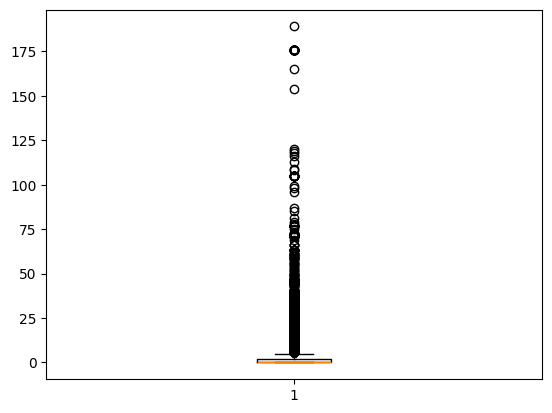

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df_copy['unresolved_violations'])
plt.show()


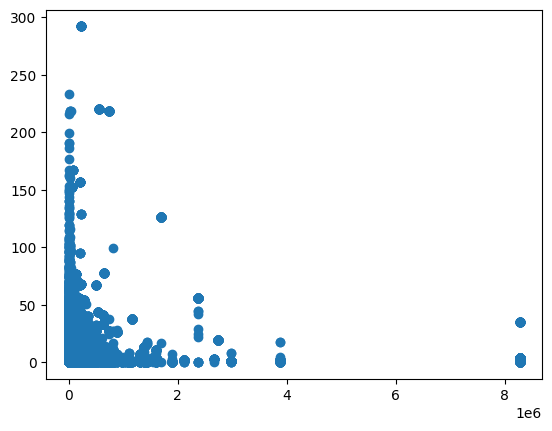

In [ ]:
plt.scatter(df_copy_two['population'], df_copy_two['total_violations'])
plt.show()


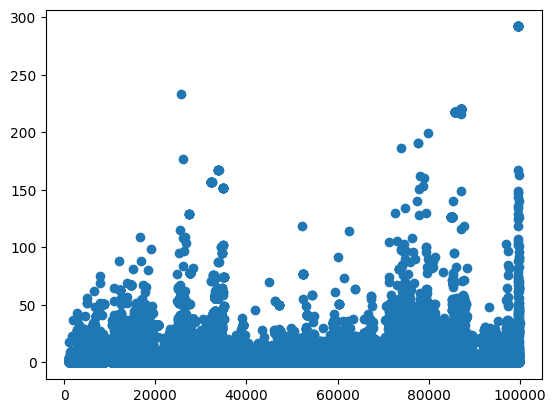

In [ ]:
plt.scatter(df_copy_two['zip'], df_copy_two['total_violations'])
plt.show()
#I think viewing the data like this is highkey not going to do anything unless I break it up into groups...
#lets seperate this lowkey..

In [ ]:
# zip code distance from source of water, there should be < toxins the farther, and > toxins closer HOWEVER the > the distance there would be more
# cholrine and bacteria thats left behind by chlorine (close)
# farther zip codes from sources would have things like e coli or smt depending on what kind of pollution the area is experiancing

In [3]:
df_copy_three["health_contaminant_names"] = df_copy_three["health_contaminant_names"].fillna("NaN")

In [4]:
df_copy_three = df_copy_three.drop_duplicates()

In [5]:
df_nodup = df_copy_three.drop_duplicates()

In [6]:
df_nodup.dropna()

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
0,1001,Agawam,MA,Agawam Water Department,MA1005000,28692.0,SW,1.0,0.0,1.0,0,NaN,42.0702,-72.6227,True
1,1002,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3671,-72.4646,True
2,1003,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3919,-72.5248,True
3,1004,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3845,-72.5132,True
4,1005,Barre,MA,Barre Water Department,MA2021000,4098.0,GW,18.0,0.0,10.0,0,NaN,42.4097,-72.1084,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41339,99926,Metlakatla,AK,KETCHIKAN PUBLIC UTILITIES,AK2120232,8937.0,SW,0.0,0.0,0.0,0,NaN,55.1215,-131.5790,False
41340,99927,Point Baker,AK,PETERSBURG,AK2130148,3218.0,SW,0.0,0.0,0.0,0,NaN,56.3528,-133.6211,False
41341,99928,Ward Cove,AK,"Ketchikan Water, Truck 1",AK2121527,100.0,SW,12.0,0.0,7.0,0,NaN,55.3954,-131.6754,False
41342,99929,Wrangell,AK,Wrangell,AK2120143,2300.0,SW,6.0,3.0,0.0,2,Total Trihalomethanes (TTHM);Stage 2 DBP Rule,56.4335,-132.3529,False


In [ ]:
df_nodup[df_nodup['zip']<2790]
df_MA = df_nodup[df_nodup['zip']<2790]
# all of the zip codes from massachusetts (i cant spell)

In [ ]:
df_MA

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
0,1001,Agawam,MA,Agawam Water Department,MA1005000,28692.0,SW,1.0,0.0,1.0,0,NaN,42.0702,-72.6227,True
1,1002,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3671,-72.4646,True
2,1003,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3919,-72.5248,True
3,1004,Amherst,MA,Amherst Dpw Water Division,MA1008000,39263.0,SW,1.0,1.0,0.0,1,E. coli,42.3845,-72.5132,True
4,1005,Barre,MA,Barre Water Department,MA2021000,4098.0,GW,18.0,0.0,10.0,0,NaN,42.4097,-72.1084,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,2771,Seekonk,MA,Seekonk Water District,MA4265000,14704.0,GW,0.0,0.0,0.0,0,NaN,41.8378,-71.3224,NaN
687,2777,Swansea,MA,Swansea Water District,MA4292000,17375.0,SW,2.0,0.0,1.0,0,NaN,41.7473,-71.2122,True
688,2779,Berkley,MA,FREETOWN WATER COMMISSION,MA4102035,1600.0,SW,0.0,0.0,0.0,0,NaN,41.8353,-71.0765,True
689,2780,Taunton,MA,Taunton Water Division,MA4293000,62165.0,SW,1.0,0.0,1.0,0,NaN,41.9050,-71.1026,True


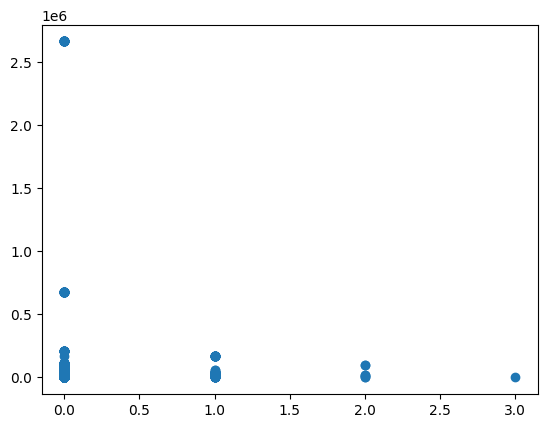

In [ ]:
plt.scatter(df_MA[p], df_MA['population'])

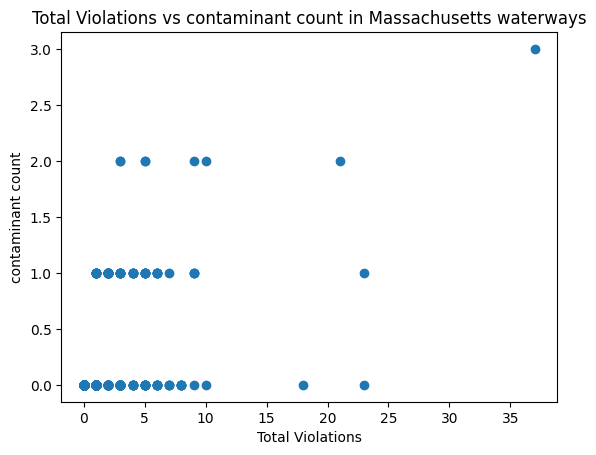

In [61]:
plt.scatter(df_MA['total_violations'], df_MA['contaminant_count'])
plt.xlabel('Total Violations')
plt.ylabel('contaminant count')
plt.title('Total Violations vs contaminant count in Massachusetts waterways')
plt.show()

health_contaminant_names
NaN                                                                   616
Total Trihalomethanes (TTHM)                                           22
Haloacetic Acids (HAA5)                                                16
Consumer Confidence Report Rule                                        11
Stage 1 DBP Rule                                                        7
E. coli                                                                 5
Contaminant 1011                                                        3
Chlorine residual;Haloacetic Acids (HAA5)                               2
Stage 2 DBP Rule;Consumer Confidence Report Rule                        2
Contaminant 0800                                                        1
Barium                                                                  1
HAA6Br                                                                  1
Consumer Confidence Report Rule;Contaminant 0700                        1
Consumer Conf

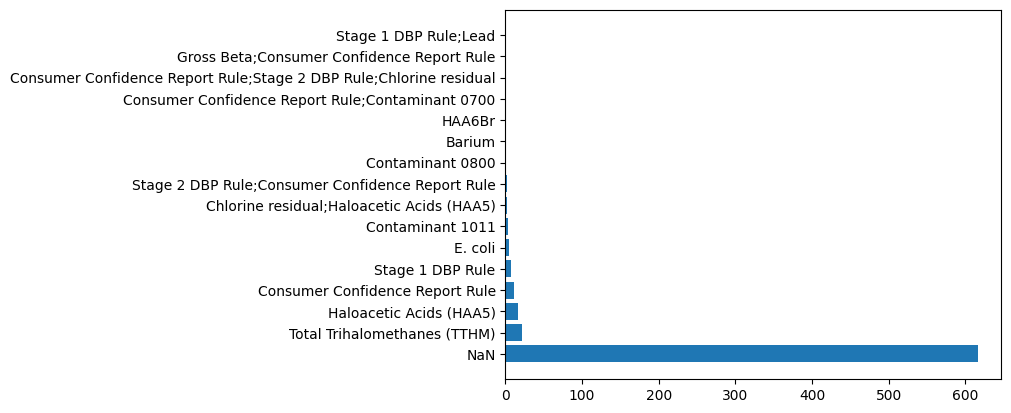

In [ ]:
counts = df_MA['health_contaminant_names'].value_counts()
plt.barh(counts.index, counts.values)
print(counts)

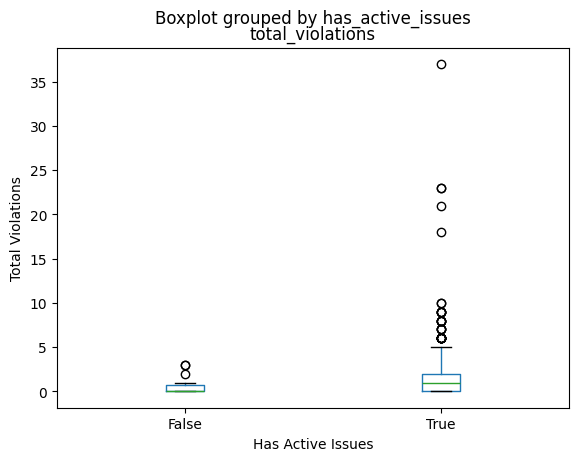

In [66]:
df_MA.boxplot(column = "total_violations", by = "has_active_issues", grid = False)
plt.ylabel("Total Violations")
plt.xlabel("Has Active Issues")

plt.show()

In [ ]:
df_MA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691 entries, 0 to 690
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       691 non-null    int64  
 1   city                      691 non-null    object 
 2   state                     691 non-null    object 
 3   system_name               691 non-null    object 
 4   pwsid                     691 non-null    object 
 5   population                691 non-null    float64
 6   water_source              691 non-null    object 
 7   total_violations          691 non-null    float64
 8   health_violations         691 non-null    float64
 9   unresolved_violations     691 non-null    float64
 10  contaminant_count         691 non-null    int64  
 11  health_contaminant_names  691 non-null    object 
 12  latitude                  691 non-null    float64
 13  longitude                 691 non-null    float64
 14  has_active_issu

In [ ]:
df_MA["has_active_issues"].value_counts(dropna=False)


,count
has_active_issues,
True,556
NaN,121
False,14


In [2]:
df_copy_three["has_active_issues"] = df_copy_three["has_active_issues"].fillna("unsure")

In [21]:
df_nodup["total_violations"].value_counts(dropna=False)

,count
total_violations,
0.0,18090
1.0,4022
2.0,3113
3.0,2527
4.0,1906
...,...
107.0,1
91.0,1
101.0,1


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import *


In [47]:
X = df_nodup[['unresolved_violations']]
y = df_nodup['total_violations']
X_train, X_test, _train, _test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print ("Linear Regression model")
print(f" MSE:{mean_squared_error (y_test, y_pred)}")
print("R2: ", r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:", lin_reg_model.intercept_)
print()

Linear Regression model
 MSE:121.47508760660081
R2:  0.685872519229408
Coefficients: [1.70795513]
Intercept: 2.400604139447509



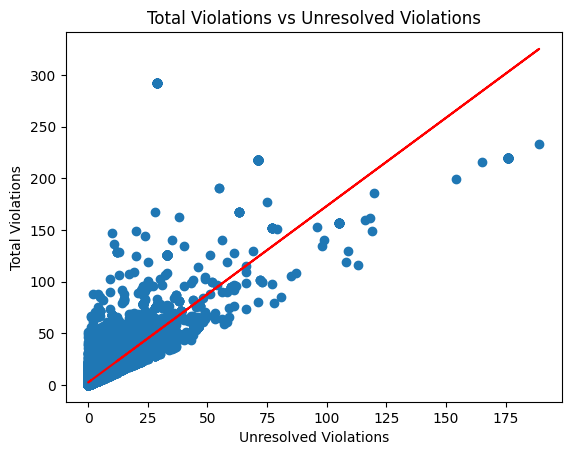

In [52]:
#scatter plot and line it
# y test vs perdicted
plt.scatter(X, y)

plt.plot(X, X*lin_reg_model.coef_+ lin_reg_model.intercept_, color = 'red', label = 'Regression Line')
plt.xlabel('Unresolved Violations')
plt.ylabel ('Total Violations')
plt.title('Total Violations vs Unresolved Violations')
plt.show()


In [46]:
X

,unresolved_violations
0,1.0
1,0.0
2,0.0
3,0.0
4,10.0
...,...
41339,0.0
41340,0.0
41341,7.0
41342,0.0


In [53]:
X = df_nodup[['health_violations']]
y = df_nodup['total_violations']
X_train, X_test, _train, _test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print ("Linear Regression model")
print(f" MSE:{mean_squared_error (y_test, y_pred)}")
print("R2: ", r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:", lin_reg_model.intercept_)
print()

Linear Regression model
 MSE:246.59977912083866
R2:  0.36230737593965545
Coefficients: [3.28811126]
Intercept: 3.1119224766699607



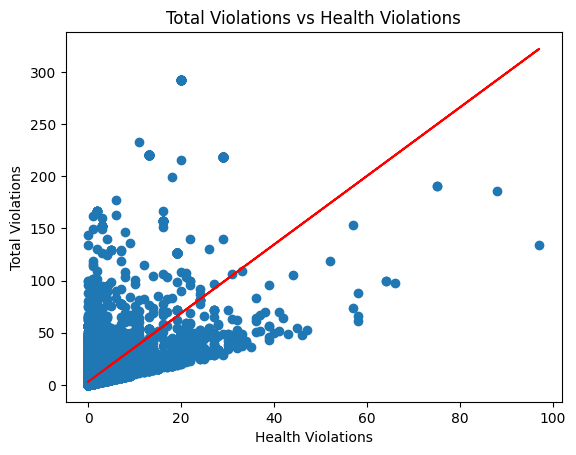

In [55]:
#scatter plot and line it
# y test vs perdicted
plt.scatter(X, y)

plt.plot(X, X*lin_reg_model.coef_+ lin_reg_model.intercept_, color = 'red', label = 'Regression Line')
plt.xlabel('Health Violations')
plt.ylabel ('Total Violations')
plt.title('Total Violations vs Health Violations')
plt.show()


In [56]:
X = df_nodup[['unresolved_violations']]
y = df_nodup['health_violations']
X_train, X_test, _train, _test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print ("Linear Regression model")
print(f" MSE:{mean_squared_error (y_test, y_pred)}")
print("R2: ", r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:", lin_reg_model.intercept_)
print()

Linear Regression model
 MSE:121.47508760660081
R2:  0.685872519229408
Coefficients: [1.70795513]
Intercept: 2.400604139447509



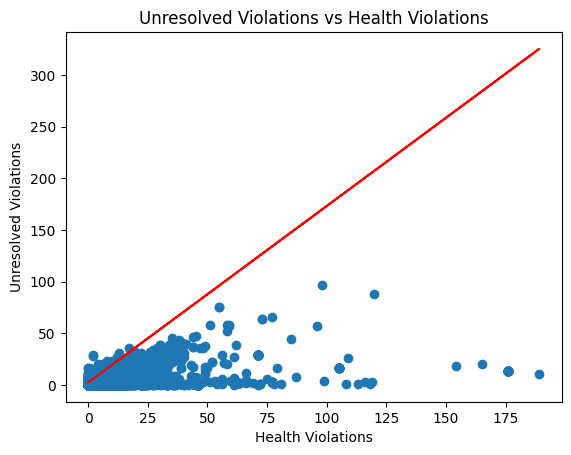

In [57]:
plt.scatter(X, y)

plt.plot(X, X*lin_reg_model.coef_+ lin_reg_model.intercept_, color = 'red', label = 'Regression Line')
plt.xlabel('Health Violations')
plt.ylabel ('Unresolved Violations')
plt.title('Unresolved Violations vs Health Violations')
plt.show()